# Getting started

In this tutorial, we will go through different features of AMICAL. You
can find a detailed description of the principal functions and associated
parameters in the API reference (see the left sidebar).

- [Step 1: clean and select data](#step-1-clean-and-select-data)
- [Step 2: extract observables](#step-2-extract-observables)
- [Step 3: calibrate V2 & CP](#step-3-calibrate-v2--cp)
- [Step 4: analyse with CANDID and
  Pymask](#step-4-analyse-with-candid-and-pymask)

First, let us import the package:

In [1]:
import amical

## Step 1: clean and select data

The major part of data coming from general pipelines (applying dark, flat,
distorsion, etc.) are not enought compliant with the Fourier extracting method
developed within AMICAL.

The first step of running AMICAL consists in cleaning the data in different ways:

- Remove residual sky background (`sky=True`, `r1`, `dr`)
- Crop and center the image (`isz`, `f_kernel=3`),
- Apply windowing (`apod`, `window`),
- Apply bad pixels correction (`bad_map=None`, `add_bad=[]`,
  `remove_bad=False`).

We use a 2d gaussian interpolation to replace the bad pixels (same as
[here](https://docs.astropy.org/en/stable/convolution/)). The keyword argument `bad_map` is
a 2D array (same shape as the data) filled with 0 and 1 where 1 stands for a bad
pixel (hot, cosmic, etc.). Instrument pipelines generally come with bad pixels
map generator, but you can add an unlimited number of bad pixels as the input
list `add_bad` (e.g.: \[[24, 08], [31, 41]])).

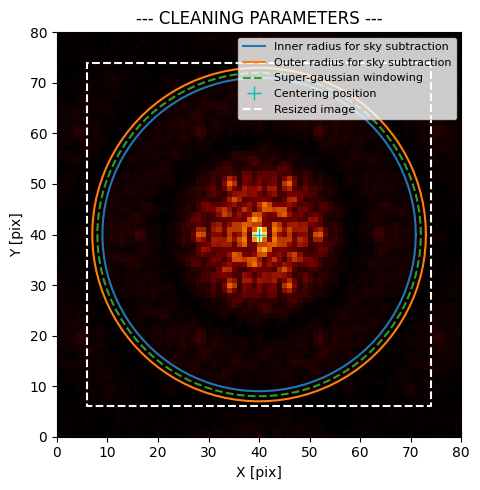

In [2]:
file_t = "./NRM_DATA/t_binary_s=147.7mas_mag=6.0_dm=6.0_posang=46.6__F430M_81_flat_x11__00.fits"
file_c = "./NRM_DATA/c_binary_s=147.7mas_mag=6.0_dm=6.0_posang=46.6__F430M_81_flat_x11__00.fits"

clean_param = {
    "isz": 69,  # final cropped image size [pix]
    "r1": 31,  # Inner radius to compute sky [pix]
    "dr": 2,  # Outer radius (r2 = r1 + dr)
    "apod": True,  # If True, apply windowing
    "window": 32,  # FWHM of the super-gaussian (for windowing)
}

# Firstly, check if the input parameters are valid
_ = amical.show_clean_params(file_t, **clean_param)

If the cleaning parameters seem well located (cyan cross on the centre, sky
radius outside the fringes pattern, etc.), we can apply the cleaning step to the
data.

Output()

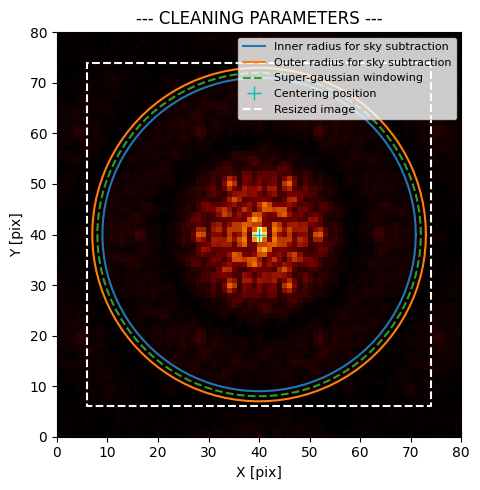

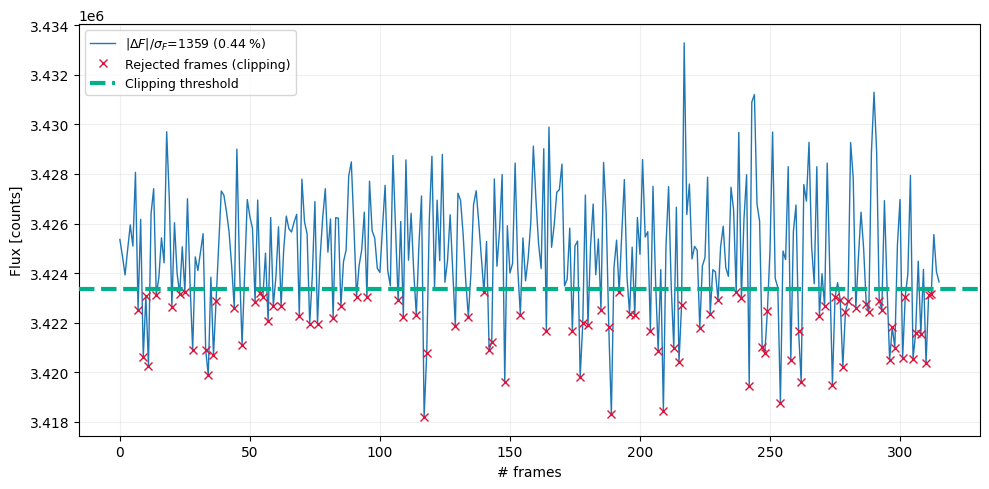

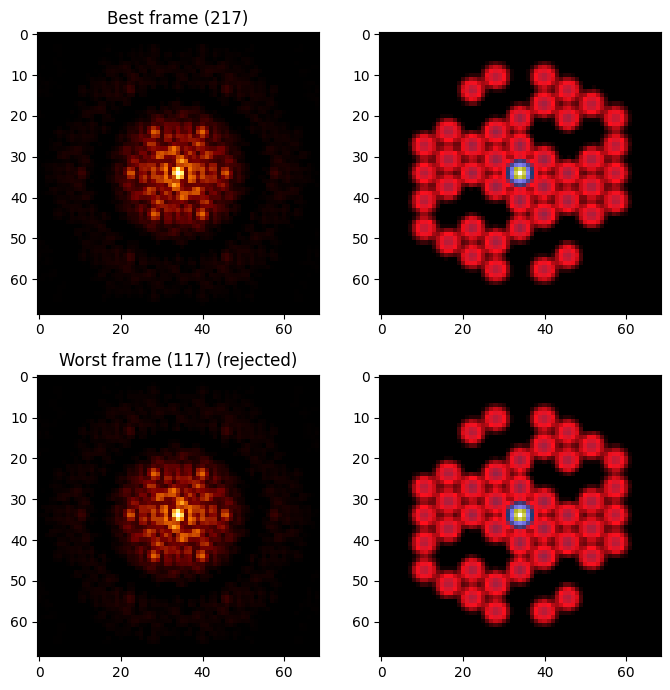

In [3]:
cube_cleaned_t = amical.select_clean_data(
    file_t, **clean_param, clip=True, clip_fact=0.5, display=True
)

During the cleaning step, you can decide to apply a lucky imaging selection
(`clip=True`) to accumulate only the best frames in the cube (based on the
integrated fluxes compared to the median: threshold = median(fluxes) -
`clip_fact` * std(fluxes)). This is shown in the second figure above.

We then repeat all the step for our reference observation.

In [4]:
cube_cleaned_c = amical.select_clean_data(
    file_c, **clean_param, clip=True, clip_fact=0.5
)

Output()

## Step 2: extract observables

The second step is the core of AMICAL: we use the Fourier sampling approach to
extract the interferometric observables (visibilities and closure phases).

The whole challenge when playing with the NRM data is to find the correct
position of each baseline in the Fourier transform. To do so, we implemented 4
different sampling methods (`peakmethod` = ('unique', 'square', 'gauss', 'fft'))
to exploit information spread beyond just the _u_, _v_ positions (see
our SPIE 2020 [reference
paper](https://ui.adsabs.harvard.edu/abs/2020SPIE11446E..11S/abstract) for more
details).

Here is an example of an image and its Fourier transform:

<p align="center">
<img src="/Figures/fft.png" alt="NIRISS Frame and its FFT" width="60%"/>
</p>

The peaks (called "splodges") in the Fourier transform are then sampled using one
of the methods shown below.

<p align="center">
<img src="/Figures/peakmethod.png" alt="Splodge Sampling Methods" width="80%"/>
</p>

Based on NIRISS and SPHERE dataset analysis, we recommend using the `'fft'`
method (but feel free to test the other methods for your specific case!). The
expected baseline locations on the detector are computed using the mask
coordinates, the wavelength and the pixel size. In some cases, the mask is not
perfectly aligned with the detector and so requires to be rotated
(`theta_detector = 0`) or centrally scaled (`scaling_uv = 1`).

With AMICAL, the mask coordinates, the wavelengths, the pixel size and the
target name are normally read from the fits file header.
In case where headers are not compliant, you will need to provide the following keyword arguments: `filtname`, `instrum` and `targetname`.

Warning: target name not found (header or as input).

/home/vandal/repos/astro/AMICAL/src/amical/tools.py:448: RuntimeWarning: No SCI header for NIRISS. No PA correction will be applied.
  l_pa = fct_pa(**kwargs_pa)


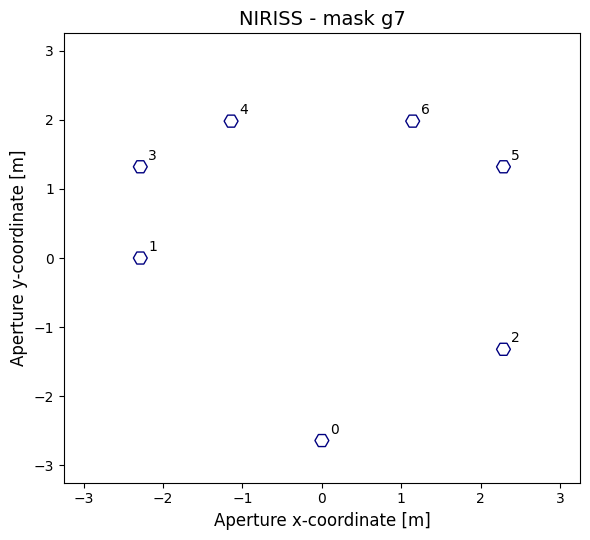

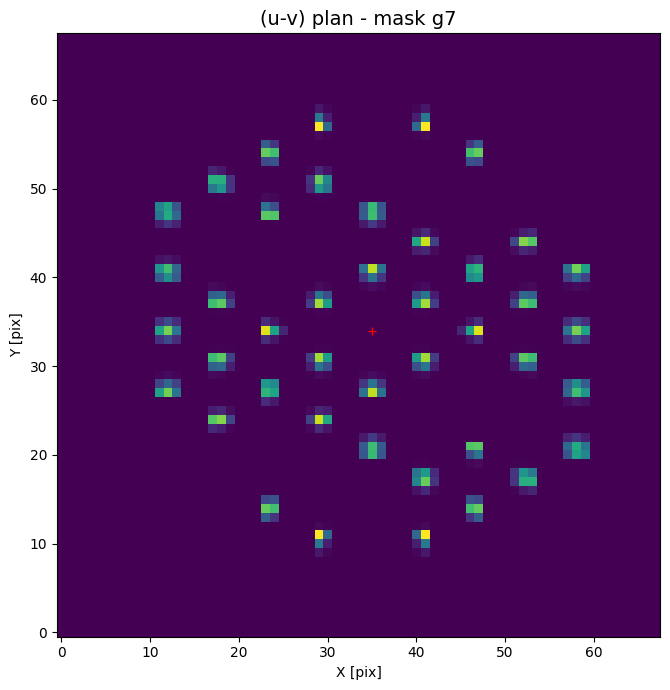

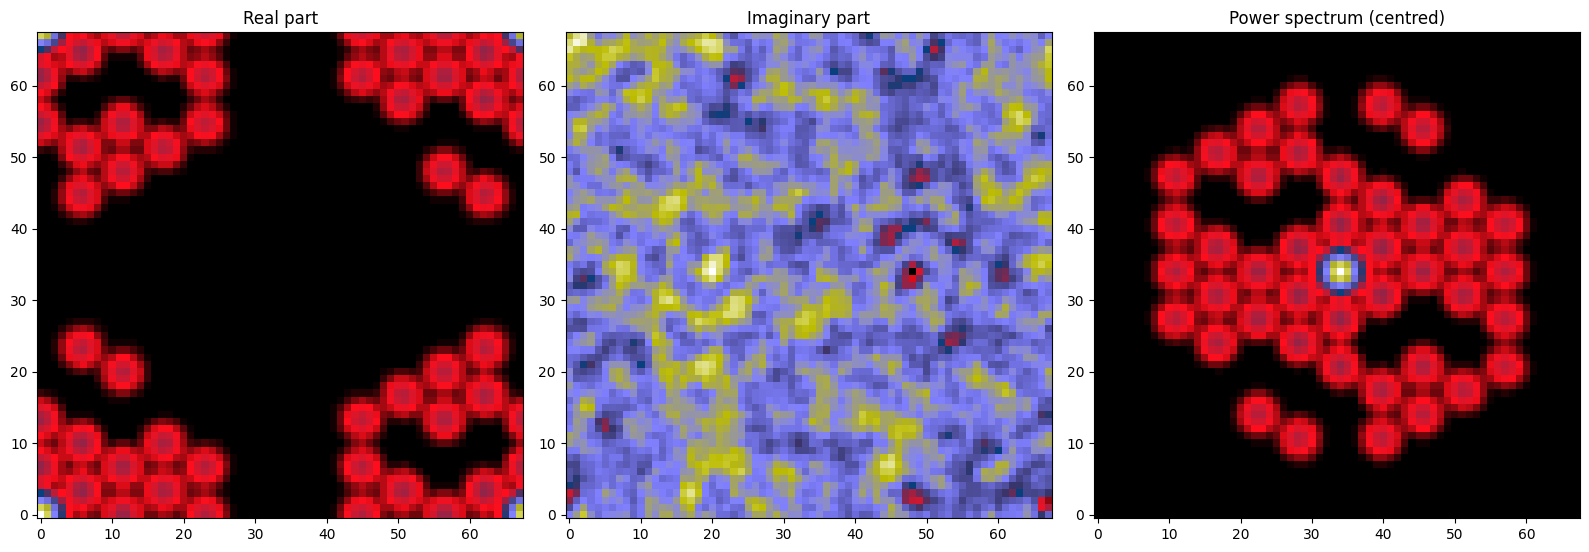

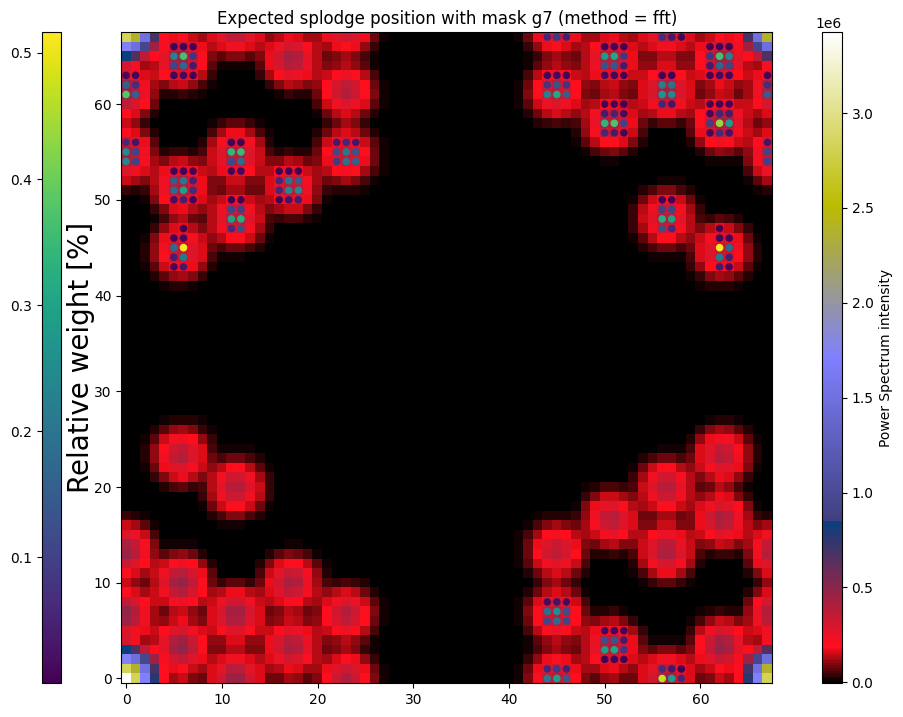

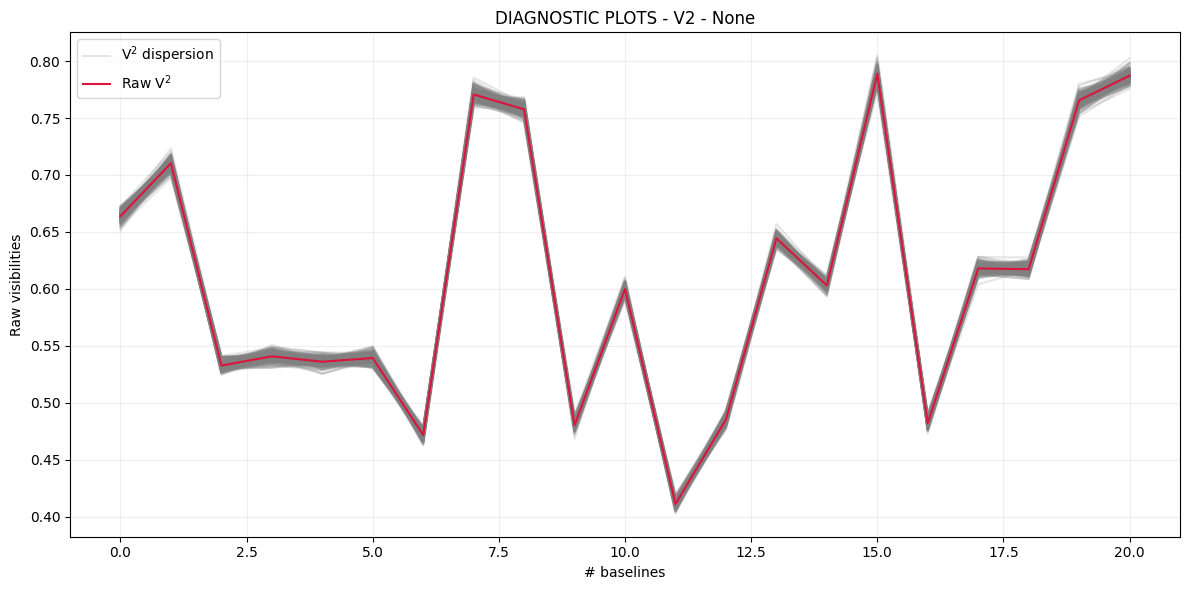

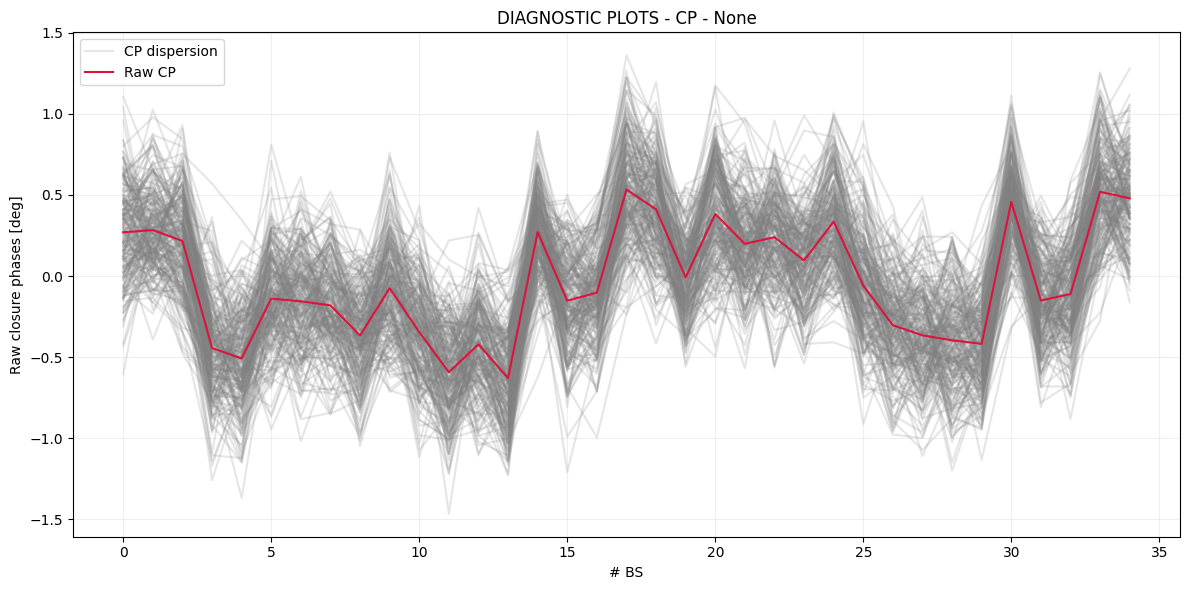

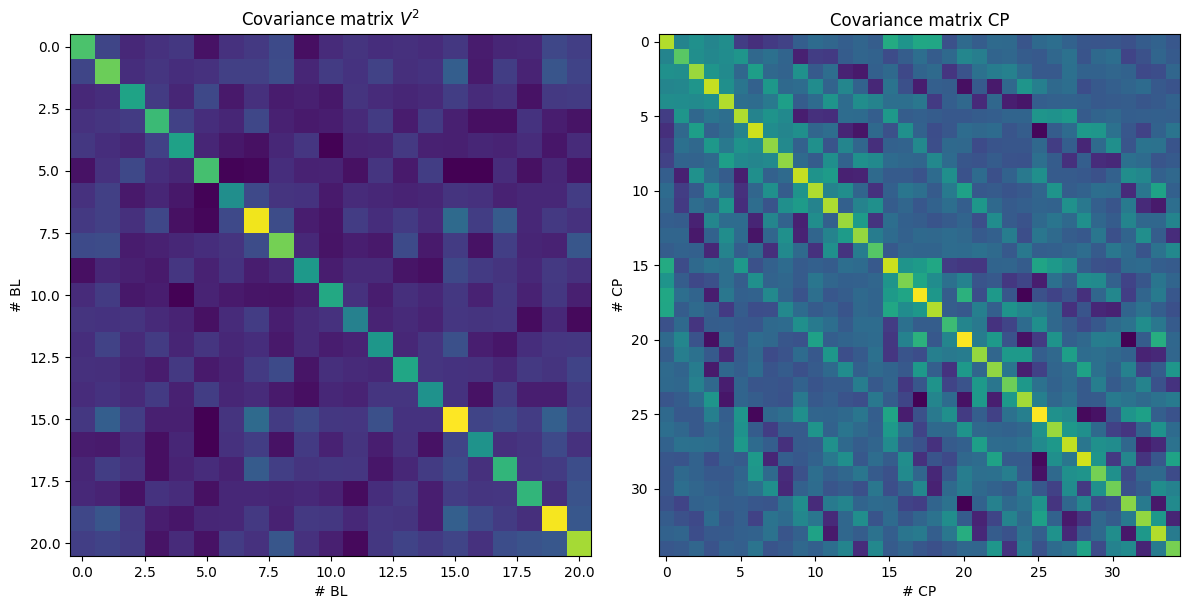

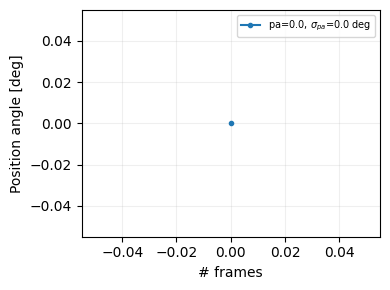

In [5]:
params_ami = {
    "peakmethod": "fft",
    "maskname": "g7",  # 7 holes mask of NIRISS
}

bs_t = amical.extract_bs(cube_cleaned_t, file_t, **params_ami)

> Note: Other parameters in `extract_bs()` are rarely modified but you
> can check [the API reference](../api/amical/mf_pipeline/bispect/#amical.mf_pipeline.bispect.extract_bs) for details.

The object `bs_t` stores the raw observables (`bs_t.vis2`, `bs_t.e_vis2`, `bs_t.cp`,
`bs_t.e_cp`), the u-v coordinates and wavelength (`bs_t.u`, `bs_t.v`, `bs_t.wl`), the
baseline lengths (`bs_t.bl`, `bs_t.bl_cp`), information relative to the used mask
(`bs_t.mask`), the computed matrices and statistic (`bs_t.matrix`) and the important
information (`bs_t.infos`). The `mask`, `infos` and `matrix` attributes also hold various data.

In [6]:
print(bs_t.keys(), bs_t.mask.keys())

dict_keys(['u', 'v', 'wl', 'e_wl', 'vis2', 'cp', 'bl', 'bl_cp', 'e_cp', 'e_vis2', 'mask', 'infos', 'matrix']) dict_keys(['bl2h_ix', 'bs2bl_ix', 'closing_tri', 'xycoord', 'n_holes', 'n_baselines', 't3_coord'])


Again, we must repeat this step for our reference observation:

In [7]:
bs_c = amical.extract_bs(cube_cleaned_c, file_c, **params_ami, display=False)

Warning: target name not found (header or as input).

## Step 3: calibrate V2 & CP

Closure phases and square visibilities suffer from systematic terms, caused by
the wavefront fluctuations (temporal, polychromatic sources, non-zero size mask,
etc.). To calibrate aperture masking data, these quantities are measured on one or several identified unresolved (or known size) calibration stars. In practice, we subtract the
calibrator signal from the raw closure phases and normalize the target
visibilities by the calibrator’s visibilities.

In [8]:
# bs_t and bs_c are the results from amical.extract_bs() on the target and
# calibrator respectively.
cal = amical.calibrate(bs_t, bs_c)

If several calibrators are available, the calibration factors are computed using
a weighted average to account for variations between sources. In this case,
`bs_c` will be a list of results from `amical.extract_bs()`. The extra errors
induced are then quadratically added to the calibrated uncertainties.

During the calibration procedure, a second data selection can be performed to
reject bad calibrator-source pairs using a sigma-clipping approach (`clip=True`,
using a threshold value in sigma `sig_thres=2`).

```python
cal = amical.calibrate(bs_t, [bs_c1, bs_c2, bs_c3], clip=True, sig_thres=2)
```

> Note: For ground based facilities, two additional corrections can be applied
> on V2 to deal with potential piston between holes (`apply_phscorr=True`) or
> seeing/wind shacking variations (`apply_atmcorr=True`). This functionnality
> was only tested on old dataset from the previous IDL pipeline, and so needs to
> be cautiously used (seem to not working on SPHERE data).
>
> Note: You can decide to normalize the CP uncertaintities by sqrt(n_holes/3)
> take into account the dependant vs. independant closure phases
> (`normalize_err_indep=True`).

Once again, `cal` is an object containing the calibrated observables
(`cal.vis2`, `cal.e_vis2`, etc.), u-v coordinates (`cal.u`, `cal.v`, `cal.u1`,
`cal.v2`, etc.), wavelength (`cal.wl`) and the output objects from step 2
(`cal.raw_t`, `cal.raw_c`).

You can now visualize the calibrated observables with `amical.show()` and save
them as the standard oifits file with amical.save().


 -- SHOW -- Inputs are classes from amical.calibrate:
-> (Check true_flag_v2, true_flag_t3 and snr parameters)



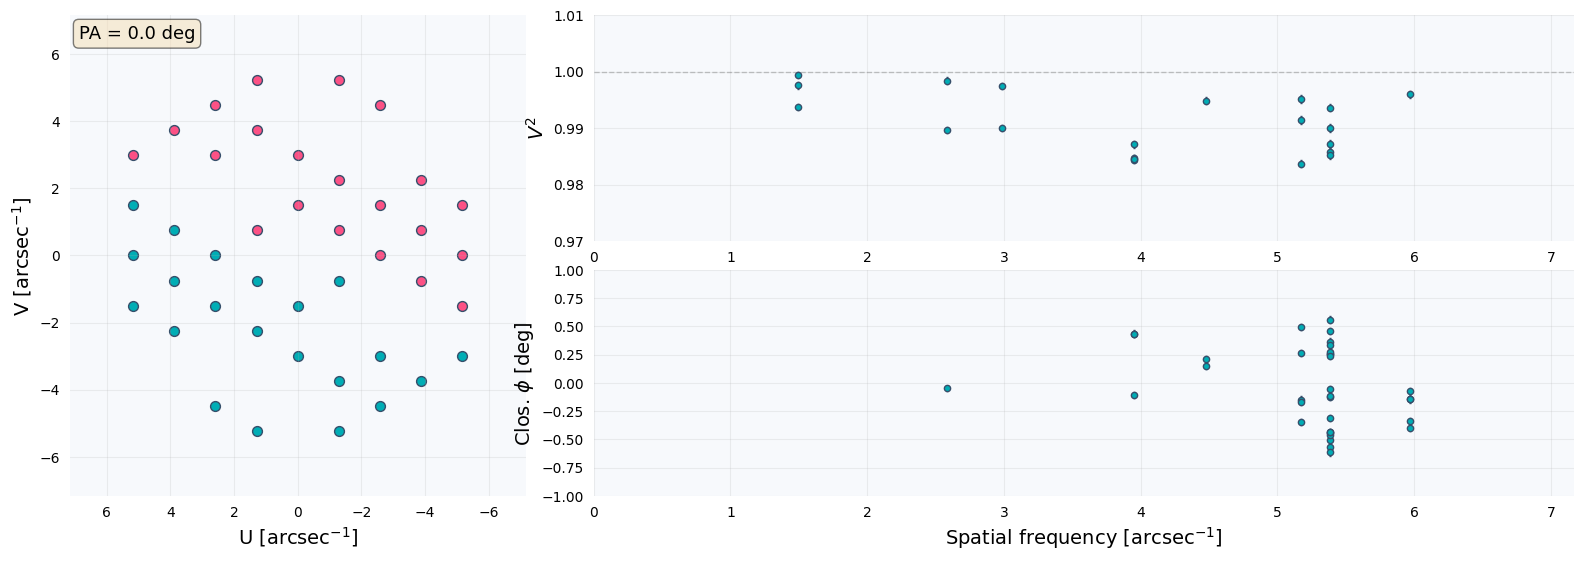

In [9]:
_ = amical.show(cal, cmax=1, vmin=0.97, vmax=1.01)

By default, we assume that the u-v plan is oriented on the detector
(north-up, east-left) with `pa=0` in degrees. The true position angle is
normally computed during the step 2 (not yet available for all instruments) and
so need to be given as input with `pa=bs.infos.pa`.

Few other parameters are available to set the axe limites (`vmax`, `vmin`,
`cmax`), set units (`unit`, `unit_cp`), log scale (`setlog`), flags
(`true_flag_v2`, `true_flag_cp`), etc.

In [10]:
oifits_file = "my_oifits_results.oifits"

_ = amical.save(cal, oifits_file, pa=bs_t.infos.pa)

If you want to save the independent CP only, you can add `ind_hole=0`
(0..n_holes-1) to select only the CP with the given aperture index. The others
parameters can be check in the docstrings.

> Note: If data are extracted from a fake target, you have to add
> `fake_obj=True` to ignore the SIMBAD search.

## Step 4: analyse with CANDID and Pymask

Finally, you can fit the data using CANDID or Pymask (two independant and
stand-alone packages).

First, you can use CANDID to fit the data using a grid search approach.

 | --- Start CANDID fitting --- :

 | loading file Saveoifits/my_oifits_results.oifits
 | observables available: [ 'cp', 't3', 'v2']
 | instruments: [ 'NIRISS']
 | best fit diameter (UD): 13.375 +- 1.185 mas (χ2 = 128.966)
 | Grid Fitting on 481 starting points (Pooling 12 processors): ... (it should take about 18 seconds)
 [==========================================================  ] 97%,     0 s (remaining)
 | Grid of fit took 3.3 seconds
 | current grid step (20.00mas) is too fine!!! --> 100.00mas should be enough


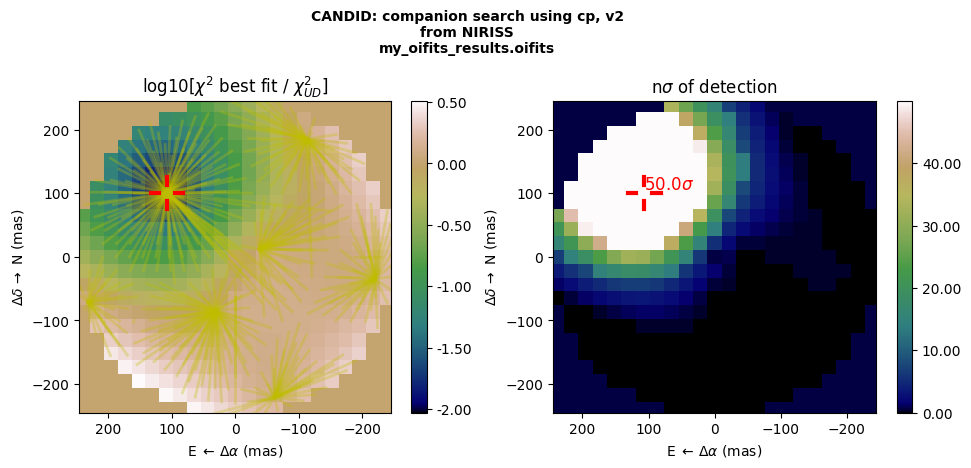

Results binary fit (χ2 = 1.0, nσ = 50.0):
-------------------

Sep = 146.4 +/- 0.8 mas
Theta = 46.8 +/- 0.3 deg
CR = 245.9 +/- 2.4
dm = 5.98 +/- 0.01


In [11]:
inputdata = "Saveoifits/my_oifits_results.oifits"

param_candid = {
    "rmin": 20,  # inner radius of the grid
    "rmax": 250,  # outer radius of the grid
    "step": 20,  # grid sampling
    "ncore": 12,  # core for multiprocessing
}

fit1 = amical.candid_grid(inputdata, **param_candid, diam=0, doNotFit=["diam*"])

And an estimate of the contrast limit.

 | --- Start CANDID contrast limit --- :

 | loading file Saveoifits/my_oifits_results.oifits
 | observables available: [ 'cp', 't3', 'v2']
 | instruments: [ 'NIRISS']
 | observables: ['cp', 'v2'] from ['cp', 't3', 'v2']
 | instruments: ['NIRISS'] from ['NIRISS']
 | best fit diameter (UD): 1.353 +- 1.003 mas (χ2 = 0.966)
 | Detection Limit Map 25x25 (Pooling 12 processors): ... it should take about 65 seconds
 | Method: injection
 [============================================================] 100%,     0 s (remaining)


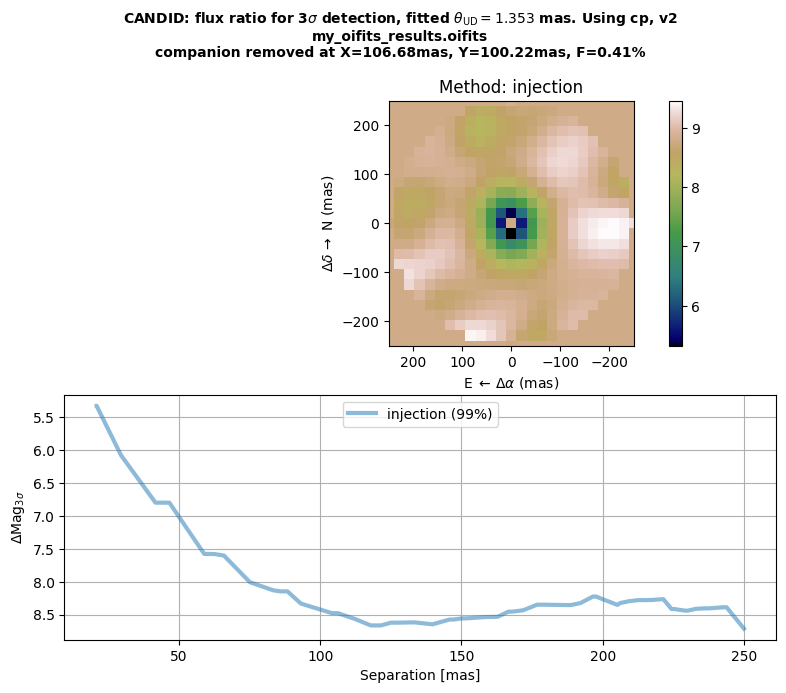

In [12]:
cr_candid = amical.candid_cr_limit(inputdata, **param_candid, fitComp=fit1["comp"])

For a detailed description and the use of Pymask package (using the MCMC
approach), you can check the [companion search tutorial](./tutorials/companion-search.ipynb) script.